In [1]:
import numpy as np
import os
from scipy.special import expit
from scipy.stats import norm
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle as pkl
from estimate_SB import _gibbs_one_iter, schbridge, sinkhorn, cost_matrix
from SB_scheme_Entropy import entropy_SB_scheme_sinkhorn
from matplotlib.animation import FuncAnimation
import time

/home/medhaaga/miniconda3/envs/quickstart/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import matplotlib as mpl

mpl.rcParams['lines.linewidth'] = 1
mpl.rcParams['xtick.labelsize'] = 30
mpl.rcParams['ytick.labelsize'] = 30
mpl.rcParams["axes.labelsize"] = 30
mpl.rcParams['legend.fontsize'] = 30
mpl.rcParams['axes.titlesize'] = 30
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [3]:
def forward_SB_var(sigma_squared, eps, k=1):

    new_sigma_squared = ((2 - (sigma_squared/(np.sqrt((sigma_squared**2) + (eps**2)/4) + eps/2)))**2)*sigma_squared

    if k==1:
        return new_sigma_squared
    elif k==0:
        return sigma_squared
    else:
        return forward_SB_var(new_sigma_squared, eps, k=k-1)


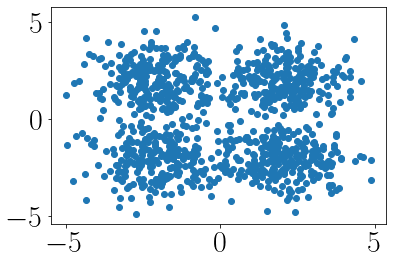

In [4]:
mu1, mu2, mu3, mu4 = np.array([2,2]), np.array([-2,2]), np.array([-2,-2]), np.array([2,-2])
N = 1000
X0 = np.concatenate([np.random.normal(loc=mu1, size=(N//4,2)),
                    np.random.normal(loc=mu2, size=(N//4,2)),
                    np.random.normal(loc=mu3, size=(N//4,2)),
                    np.random.normal(loc=mu4, size=(N//4,2))])

plt.scatter(X0[:,0], X0[:,1])

In [5]:
X_trajectory =  entropy_SB_scheme_sinkhorn(X0, steps=[10, 20, 30, 40, 50], eps=0.01, precision=1e-8, maxiter=1e6, forward=True, dir=None)

  0%|          | 0/50 [00:00<?, ?it/s]

(1000, 1000, 2)


  0%|          | 0/50 [00:01<?, ?it/s]


TypingError: Failed in nopython mode pipeline (step: nopython frontend)
Failed in nopython mode pipeline (step: nopython frontend)
No implementation of function Function(<intrinsic _impl>) found for signature:
 
 >>> _impl(array(float64, 2d, C), array(float64, 3d, C))
 
There are 2 candidate implementations:
  - Of which 2 did not match due to:
  Intrinsic in function 'dot_2_impl.<locals>._impl': File: numba/np/linalg.py: Line 543.
    With argument(s): '(array(float64, 2d, C), array(float64, 3d, C))':
   Rejected as the implementation raised a specific error:
     TypingError: '@': inputs must have compatible dimensions
  raised from /home/medhaaga/.local/lib/python3.10/site-packages/numba/np/linalg.py:573

During: resolving callee type: Function(<intrinsic _impl>)
During: typing of call at /home/medhaaga/.local/lib/python3.10/site-packages/numba/np/linalg.py (582)


File "../.local/lib/python3.10/site-packages/numba/np/linalg.py", line 582:
            def _dot2_codegen(context, buil

In [6]:
def cost_matrix(X, Y):
    """L2 cost matrix
    """
    X = X.reshape(X.shape[0], -1)
    Y = Y.reshape(Y.shape[0], -1)

    return (X[:, None, :] - Y[None, :, :])**2

X0 = np.random.normal(size=(1000,2))
cost = cost_matrix(X0, X0)

In [7]:
cost.shape

(1000, 1000, 2)